In [1]:
import pandas as pd
data=pd.read_csv("TATACOFFEE13_21.csv")
data

,Date,Open,High,Low,Close
0,2013-01-01,1410.60,1427.90,1408.30,1415.10
1,2013-01-02,1421.00,1626.60,1416.15,1607.40
2,2013-01-03,1632.55,1673.90,1613.05,1626.20
3,2013-01-04,1627.75,1627.75,1574.60,1579.05
4,2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...,...
2220,2021-12-22,202.90,207.80,201.35,205.00
2221,2021-12-23,206.00,206.85,202.05,202.95
2222,2021-12-24,203.90,203.90,199.35,201.00
2223,2021-12-27,200.00,222.00,196.00,218.35


In [2]:
column = "Close"

from sklearn.preprocessing import MinMaxScaler

Ms = MinMaxScaler()

data1 = Ms.fit_transform(data[[column]])

print("Len:", data1.shape)

Len: (2225, 1)


In [3]:
training_size = round(len(data1) * 0.95)

print(training_size)

X_train = data1[:training_size]
X_test = data1[training_size:]

print("X_train length:", X_train.shape)
print("X_test length:", X_test.shape)

y_train = data1[:training_size]
y_test = data1[training_size:]

print("y_train length:", y_train.shape)
print("y_test length:", y_test.shape)

2114
X_train length: (2114, 1)
X_test length: (111, 1)
y_train length: (2114, 1)
y_test length: (111, 1)


In [5]:
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

trends = ['n', 'ct']
orders = [(0, 0, 1), (0, 0, 2)]

for i in orders:

    for td in trends:

        model = ARIMA(
            X_train,
            order=i,
            trend=td
        )

        model_fit = model.fit()

        # Make prediction
        y_pred = model_fit.predict(
            len(X_train),
            len(data1) - 1
        )

        mse = mean_squared_error(
            y_test,
            y_pred
        )

        from stockFunctions import rmsemape

        print("Order={0}, Trend={1}".format(i, td))
        rmsemape(y_test, y_pred)
        print("***************")

D:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Order=(0, 0, 1), Trend=n
RMSE-Testset: 0.10043760019646018
MAPE-Testset: 0.9957928097006858
***************


D:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
D:\Users\admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
D:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Order=(0, 0, 1), Trend=ct
RMSE-Testset: 0.2831823148789008
MAPE-Testset: 2.820151902251245
***************
Order=(0, 0, 2), Trend=n
RMSE-Testset: 0.10022658964272009
MAPE-Testset: 0.9911283585085614
***************


D:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Order=(0, 0, 2), Trend=ct
RMSE-Testset: 0.2831823148789008
MAPE-Testset: 2.820151902251245
***************


D:\Users\admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


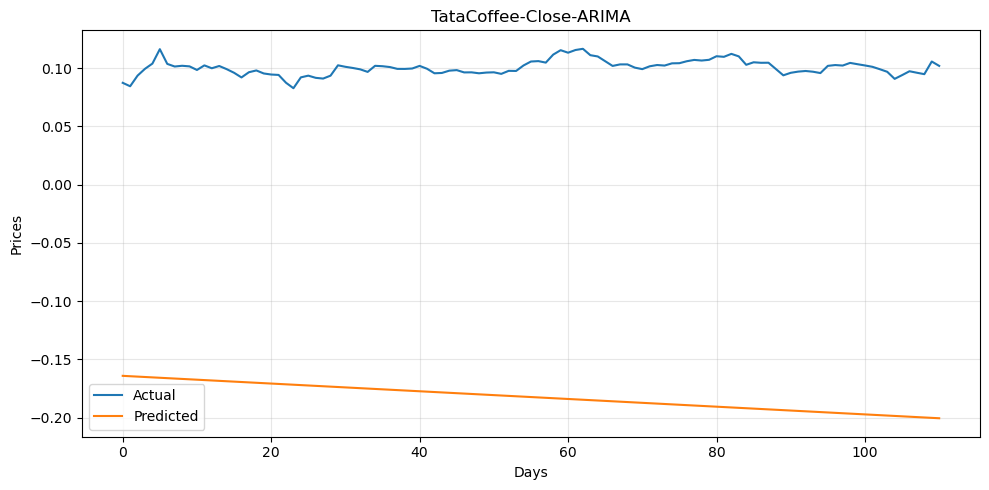

In [6]:
from stockFunctions import graph

graph(
    y_test,
    y_pred,
    "Actual",
    "Predicted",
    "TataCoffee-Close-ARIMA",
    "Days",
    "Prices"
)

In [10]:
len(data)

2225

In [8]:
from stockFunctions import conversionSingle

aTestNormalTable = conversionSingle(
    y_test,
    [column]
)

actual_stock_price_test_ori = Ms.inverse_transform(
    aTestNormalTable
)

In [11]:
from stockFunctions import conversionSingle

aTestNormalTable = conversionSingle(
    y_test,
    [column]
)

actual_stock_price_test_ori = Ms.inverse_transform(
    aTestNormalTable
)

predicted_stock_price_test_ori = conversionSingle(
    y_pred,
    [column]
)

predicted_stock_price_test_ori = Ms.inverse_transform(
    predicted_stock_price_test_ori
)